# SPATNIC Model Training

このノートブックでは以下の2つのモデルを学習し、SPATNICパッケージ用のチェックポイントとしてエクスポートします。

| Model | Task | Classes |
|-------|------|---------|
| `tumor_normal` | がん細胞 vs 正常上皮細胞 | Normal (0), Tumor (1) |
| `tumor_other` | がん細胞 vs その他すべて | Other (0), Tumor (1) |

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc,
)
import matplotlib.pyplot as plt
import os

sc.settings.set_figure_params(dpi=100, facecolor="white")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Device: {device}")

Device: cuda


In [3]:
# SPATNIC パッケージのインストール（未インストールの場合）
# !pip install /mnt/g/ubuntu_backup/spatnic

from spatnic import StudentTVAECls, export_checkpoint

In [5]:
# 出力先は ~/.spatnic/weights/ に自動保存されます

## 2. Data Loading

In [13]:
adata_raw = ad.read_h5ad("../../integrate_adata_filtered.h5ad")

# Doublet 除外
adata_raw = adata_raw[
    adata_raw.obs["Cell_type_integrate"] != "Tumor-infiltrating immune cell"
].copy()

# Major cluster 列の作成
adata_raw.obs["Major_cluster"] = adata_raw.obs["Cell_type_integrate"].replace({
    "Endothelial": "Stromal", "CAF": "Stromal", "Fibroblast": "Stromal",
    "Tumor": "Epithelial",
})

adata_raw.obs["Major_cluster_pathol"] = adata_raw.obs["Cell_type_integrate"].replace({
    "Endothelial": "Stromal", "CAF": "Stromal", "Fibroblast": "Stromal",
    "Epithelial": "Normal",
})

print(adata_raw)
print("\nCell_type_integrate:")
print(adata_raw.obs["Cell_type_integrate"].value_counts())
print("\nMajor_cluster_pathol:")
print(adata_raw.obs["Major_cluster_pathol"].value_counts())

AnnData object with n_obs × n_vars = 2829869 × 5001
    obs: 'imagecol', 'imagerow', 'Cluster', 'Cell_type', 'Sample', 'Timepoint', 'Patient', 'Response', 'Relapse', 'Slide', 'Run', 'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'QC', 'new_leiden', 'Cell_type_integrate', 'sample', 'Major_cluster', 'Major_cluster_pathol'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'Cell_type_colors', 'Patient_colors', 'QC_colors', 'Sample_colors', 'dendrogram_leiden', 'dendrogram_new_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'new_leiden_colors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Cell_ty

/tmp/ipykernel_138641/1350382357.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_raw.obs["Major_cluster"] = adata_raw.obs["Cell_type_integrate"].replace({
/tmp/ipykernel_138641/1350382357.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_raw.obs["Major_cluster_pathol"] = adata_raw.obs["Cell_type_integrate"].replace({


## 3. Training Utilities

In [14]:
# ===== 疎行列ユーティリティ =====

def csr_mean_std(X_csr):
    """CSR 行列の列方向 mean / std を計算する。"""
    mean = np.array(X_csr.mean(axis=0)).ravel()
    X2 = X_csr.copy(); X2.data = X2.data ** 2
    mean2 = np.array(X2.mean(axis=0)).ravel()
    var = np.maximum(mean2 - mean ** 2, 1e-8)
    std = np.sqrt(var)
    return mean.astype(np.float32), std.astype(np.float32)


def standardize_csr(X_csr, mean, std):
    """CSR 行列を列方向に標準化する。"""
    X = X_csr.tocoo(copy=True)
    col_std = std[X.col].copy()
    col_std[col_std == 0] = 1.0
    X.data = (X.data - mean[X.col]) / col_std
    return X.tocsr()


# ===== Dataset =====

class SparseDataset(Dataset):
    def __init__(self, X, y):
        self.X = sp.csr_matrix(X) if not sp.isspmatrix_csr(X) else X
        self.y = np.asarray(y, dtype=np.int64)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        row = self.X.getrow(i).toarray().ravel().astype(np.float32)
        return torch.from_numpy(row), torch.tensor(int(self.y[i]), dtype=torch.long)


# ===== 損失関数 =====

def kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)


def student_t_nll(x, mu, logvar, nu):
    var = logvar.exp().clamp_min(1e-8)
    sq = (x - mu) ** 2
    return (0.5 * torch.log(var) + 0.5 * (nu + 1.0) * torch.log1p(sq / (nu * var))).sum(dim=1)

In [15]:
# ===== 学習・評価関数 =====

def prepare_data(adata_subset, label_col, label_map, n_top_genes=3000,
                 n_sample_per_class=None, test_size=0.2, random_state=42):
    """
    AnnData からラベル付与 → サンプリング → HVG 抽出 → 分割 → 標準化 まで行う。
    
    Returns
    -------
    dict with keys:
        train_loader, val_loader, gene_names, mu_g, std_g,
        n_genes, n_classes, y_te, cell_ids_test
    """
    adata = adata_subset.copy()
    adata.obs["label"] = adata.obs[label_col].map(label_map)
    adata = adata[adata.obs["label"].notna()].copy()
    adata.obs["label"] = adata.obs["label"].astype(int)

    # クラスごとにサンプリング（バランス調整）
    if n_sample_per_class is not None:
        sampled_idx = []
        for lab in sorted(adata.obs["label"].unique()):
            pool = adata.obs[adata.obs["label"] == lab].index
            n = min(n_sample_per_class, len(pool))
            sampled_idx.append(
                pd.Series(pool).sample(n=n, random_state=random_state).values
            )
        selected = np.concatenate(sampled_idx)
        adata = adata[selected].copy()

    print(f"  Cells: {adata.n_obs:,}, label distribution:")
    print(adata.obs["label"].value_counts().sort_index().to_string())

    # HVG 抽出
    sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes, flavor="seurat")
    adata_hvg = adata[:, adata.var.highly_variable].copy()

    X_all = adata_hvg.X
    if not sp.isspmatrix_csr(X_all):
        X_all = sp.csr_matrix(X_all)
    y_all = adata_hvg.obs["label"].values
    cell_ids = adata_hvg.obs_names.values
    gene_names = np.array(adata_hvg.var_names)

    # Train / Test 分割
    idx = np.arange(X_all.shape[0])
    idx_tr, idx_te = train_test_split(
        idx, test_size=test_size, stratify=y_all, random_state=random_state
    )

    X_tr, X_te = X_all[idx_tr], X_all[idx_te]
    y_tr, y_te = y_all[idx_tr], y_all[idx_te]

    # 標準化パラメータ（学習セットから算出）
    mu_g, std_g = csr_mean_std(X_tr)
    X_tr_std = standardize_csr(X_tr, mu_g, std_g)
    X_te_std = standardize_csr(X_te, mu_g, std_g)

    BATCH = 1024
    train_loader = DataLoader(
        SparseDataset(X_tr_std, y_tr), batch_size=BATCH,
        shuffle=True, num_workers=4, pin_memory=True,
    )
    val_loader = DataLoader(
        SparseDataset(X_te_std, y_te), batch_size=BATCH,
        shuffle=False, num_workers=4, pin_memory=True,
    )

    n_genes = X_all.shape[1]
    n_classes = len(np.unique(y_all))

    return {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "gene_names": gene_names,
        "mu_g": mu_g,
        "std_g": std_g,
        "n_genes": n_genes,
        "n_classes": n_classes,
        "y_te": y_te,
        "cell_ids_test": cell_ids[idx_te],
    }


def train_model(data, epochs_pre=8, epochs_joint=40,
                beta_kl=0.1, lambda_cls=2.0, lr=1e-3, weight_decay=1e-2):
    """
    Student-t VAE + Classifier を学習する。
    2段階: 前学習（再構成+KL） → 共同学習（再構成+KL+分類）。
    """
    model = StudentTVAECls(
        in_dim=data["n_genes"],
        n_classes=data["n_classes"],
        latent_dim=32, hidden=512,
        dropout=0.2, denoise_p=0.2,
        heteroscedastic=True, stu_nu=5.0, learnable_nu=False,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_joint)

    def run_epoch(loader, train=True, joint=False):
        model.train(train)
        n, rec_s, kl_s, cls_s, acc_s = 0, 0., 0., 0., 0.
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            mu_z, logvar_z, dec_out, logvar_x, logits = model(xb)

            nu = model.current_nu()
            rec = student_t_nll(xb, dec_out, logvar_x, float(nu)).mean()
            kl = kl_divergence(mu_z, logvar_z).mean()

            if joint:
                cls = F.cross_entropy(logits, yb)
                loss = rec + beta_kl * kl + lambda_cls * cls
            else:
                cls = torch.tensor(0., device=device)
                loss = rec + beta_kl * kl

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

            bs = yb.size(0)
            n += bs
            rec_s += rec.item() * bs
            kl_s += kl.item() * bs
            if joint:
                cls_s += cls.item() * bs
                acc_s += (logits.argmax(1) == yb).float().sum().item()

        if train:
            scheduler.step()
        if joint:
            return rec_s/n, kl_s/n, cls_s/n, acc_s/n
        return rec_s/n, kl_s/n

    best_state, best_acc = None, -1.0

    # Stage 1: Pretrain (reconstruction + KL)
    print("== Pretrain (reconstruction + KL) ==")
    for ep in range(1, epochs_pre + 1):
        tr_rec, tr_kl = run_epoch(data["train_loader"], train=True, joint=False)
        va_rec, va_kl = run_epoch(data["val_loader"], train=False, joint=False)
        print(f"  [pre {ep:02d}] train rec={tr_rec:.4f} kl={tr_kl:.4f}"
              f" | val rec={va_rec:.4f} kl={va_kl:.4f}")

    # Stage 2: Joint (reconstruction + KL + classification)
    print("== Joint (reconstruction + KL + classification) ==")
    for ep in range(1, epochs_joint + 1):
        tr_rec, tr_kl, tr_cls, tr_acc = run_epoch(
            data["train_loader"], train=True, joint=True
        )
        va_rec, va_kl, va_cls, va_acc = run_epoch(
            data["val_loader"], train=False, joint=True
        )
        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"  [joint {ep:02d}] train rec={tr_rec:.4f} kl={tr_kl:.4f}"
              f" cls={tr_cls:.4f} acc={tr_acc:.4f}"
              f" | val rec={va_rec:.4f} kl={va_kl:.4f}"
              f" cls={va_cls:.4f} acc={va_acc:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\nBest validation accuracy: {best_acc:.4f}")
    return model


def evaluate_model(model, data, class_names):
    """推論 → Confusion Matrix, Classification Report, ROC-AUC を出力する。"""
    model.eval()
    all_probs, all_preds = [], []
    with torch.no_grad():
        for xb, _ in data["val_loader"]:
            xb = xb.to(device)
            logits = model(xb)[-1]
            prob = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.append(prob)
            all_preds.append((prob >= 0.5).astype(int))

    y_score = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    y_true = data["y_te"]

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))

    try:
        roc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC: {roc:.6f}")
    except Exception:
        roc = None

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Confusion Matrix")
    axes[0].grid(False)

    if roc is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        axes[1].plot(fpr, tpr, label=f"AUC = {roc:.4f}")
        axes[1].plot([0, 1], [0, 1], "--", color="gray")
        axes[1].set_xlabel("FPR")
        axes[1].set_ylabel("TPR")
        axes[1].set_title("ROC Curve")
        axes[1].legend()

    plt.tight_layout()
    plt.show()

    # FP/FN counts
    FP = int(((y_true == 0) & (y_pred == 1)).sum())
    FN = int(((y_true == 1) & (y_pred == 0)).sum())
    TN = int(((y_true == 0) & (y_pred == 0)).sum())
    TP = int(((y_true == 1) & (y_pred == 1)).sum())
    print(f"FP={FP}, FN={FN}, TN={TN}, TP={TP}")

    return {"y_pred": y_pred, "y_score": y_score, "roc_auc": roc}

---
## 4. Model 1: Tumor vs Normal (tumor_normal)

上皮細胞 (Epithelial) のみを対象に、がん細胞 (Tumor) と正常上皮 (Normal) を分類する。

In [16]:
# 上皮細胞のみ抽出
adata_epi = adata_raw[adata_raw.obs["Major_cluster"] == "Epithelial"].copy()
print(f"Epithelial cells: {adata_epi.n_obs:,}")
print(adata_epi.obs["Major_cluster_pathol"].value_counts())

Epithelial cells: 1,092,191
Major_cluster_pathol
Tumor     847682
Normal    244509
Name: count, dtype: int64


In [17]:
# データ準備
print("=" * 60)
print("Preparing tumor_normal data...")
print("=" * 60)

data_tn = prepare_data(
    adata_epi,
    label_col="Major_cluster_pathol",
    label_map={"Normal": 0, "Tumor": 1},
    n_top_genes=3000,
    n_sample_per_class=244509,  # 元のノートブックと同じ
    test_size=0.2,
    random_state=42,
)

Preparing tumor_normal data...
  Cells: 489,018, label distribution:
label
0    244509
1    244509


In [18]:
# 学習
print("=" * 60)
print("Training tumor_normal model...")
print("=" * 60)

model_tn = train_model(
    data_tn,
    epochs_pre=8,
    epochs_joint=40,
    beta_kl=0.1,
    lambda_cls=2.0,
    lr=1e-3,
    weight_decay=1e-2,
)

Training tumor_normal model...
== Pretrain (reconstruction + KL) ==
  [pre 01] train rec=-5186.9034 kl=65.2562 | val rec=-5459.1354 kl=80.0940
  [pre 02] train rec=-5496.7628 kl=67.3294 | val rec=-5524.8707 kl=86.0919
  [pre 03] train rec=-5533.9811 kl=64.3030 | val rec=-5548.6401 kl=78.1723
  [pre 04] train rec=-5557.2415 kl=60.0551 | val rec=-5566.5306 kl=74.5910
  [pre 05] train rec=-5575.5280 kl=56.7594 | val rec=-5586.1473 kl=65.2222
  [pre 06] train rec=-5587.3507 kl=53.2188 | val rec=-5596.4647 kl=61.9254
  [pre 07] train rec=-5595.7299 kl=49.7862 | val rec=-5605.4181 kl=56.5381
  [pre 08] train rec=-5601.7305 kl=46.7855 | val rec=-5612.5312 kl=51.4826
== Joint (reconstruction + KL + classification) ==
  [joint 01] train rec=-5606.9018 kl=45.0946 cls=0.2152 acc=0.9258 | val rec=-5616.1788 kl=50.9165 cls=0.1423 acc=0.9533
  [joint 02] train rec=-5611.6665 kl=44.2027 cls=0.1668 acc=0.9428 | val rec=-5622.3944 kl=47.9407 cls=0.1359 acc=0.9545
  [joint 03] train rec=-5615.8010 kl=43

Evaluation: tumor_normal
Confusion Matrix:
[[46900  2002]
 [ 1904 46998]]

              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96     48902
       Tumor       0.96      0.96      0.96     48902

    accuracy                           0.96     97804
   macro avg       0.96      0.96      0.96     97804
weighted avg       0.96      0.96      0.96     97804

ROC-AUC: 0.991139


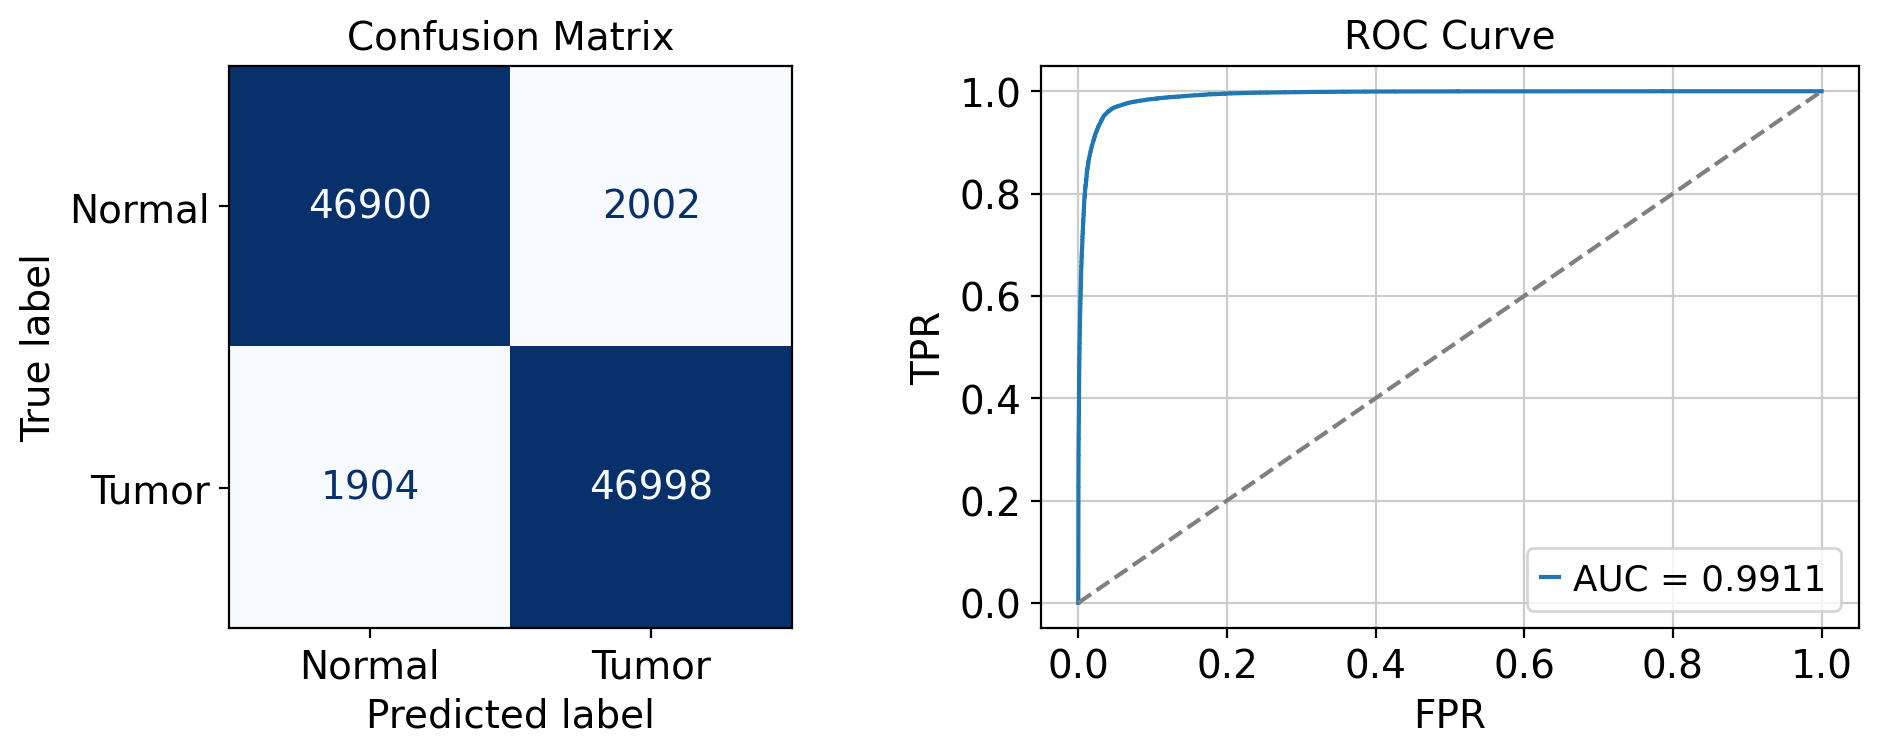

FP=2002, FN=1904, TN=46900, TP=46998


In [19]:
# 評価
print("=" * 60)
print("Evaluation: tumor_normal")
print("=" * 60)

results_tn = evaluate_model(model_tn, data_tn, class_names=["Normal", "Tumor"])

In [20]:
# チェックポイント保存（~/.spatnic/weights/ に自動保存）
_tmp_sd = "_tmp_tumor_normal_sd.pth"
torch.save(
    {k: v.cpu() for k, v in model_tn.state_dict().items()},
    _tmp_sd,
)

export_checkpoint(
    state_dict_path=_tmp_sd,
    gene_names=list(data_tn["gene_names"]),
    mu_g=data_tn["mu_g"],
    std_g=data_tn["std_g"],
    model_name="tumor_normal",
    label_map={0: "Normal", 1: "Tumor"},
)

os.remove(_tmp_sd)

[SPATNIC] Checkpoint saved to /home/shusakai/.spatnic/weights/tumor_normal.pt (20.9 MB)


---
## 5. Model 2: Tumor vs Other (tumor_other)

すべての細胞タイプを対象に、がん細胞 (Tumor) とそれ以外 (Other) を分類する。

In [21]:
# 全細胞を使用
print(f"All cells: {adata_raw.n_obs:,}")
print(adata_raw.obs["Major_cluster_pathol"].value_counts())

All cells: 2,829,869
Major_cluster_pathol
Stromal    1076538
Tumor       847682
T cell      280140
Normal      244509
B cell      211095
Myeloid     169905
Name: count, dtype: int64


In [22]:
# ラベル: Tumor=1, それ以外=0
# Tumor 以外の全カテゴリを Other にまとめる
all_labels = adata_raw.obs["Major_cluster_pathol"].unique()
label_map_to = {lab: 0 for lab in all_labels}
label_map_to["Tumor"] = 1
print("Label mapping:", label_map_to)

# Tumor の細胞数を確認してバランスを決める
n_tumor = int((adata_raw.obs["Major_cluster_pathol"] == "Tumor").sum())
print(f"\nTumor cells: {n_tumor:,}")
print(f"Other cells: {adata_raw.n_obs - n_tumor:,}")

# バランスを取るためのサンプル数（Tumor 数に合わせる）
n_sample = n_tumor
print(f"Sampling {n_sample:,} per class")

Label mapping: {'Tumor': 1, 'B cell': 0, 'Myeloid': 0, 'Stromal': 0, 'T cell': 0, 'Normal': 0}

Tumor cells: 847,682
Other cells: 1,982,187
Sampling 847,682 per class


In [23]:
# データ準備
print("=" * 60)
print("Preparing tumor_other data...")
print("=" * 60)

data_to = prepare_data(
    adata_raw,
    label_col="Major_cluster_pathol",
    label_map=label_map_to,
    n_top_genes=3000,
    n_sample_per_class=n_sample,
    test_size=0.2,
    random_state=42,
)

Preparing tumor_other data...
  Cells: 1,695,364, label distribution:
label
0    847682
1    847682


In [24]:
# 学習
print("=" * 60)
print("Training tumor_other model...")
print("=" * 60)

model_to = train_model(
    data_to,
    epochs_pre=8,
    epochs_joint=40,
    beta_kl=0.1,
    lambda_cls=2.0,
    lr=1e-3,
    weight_decay=1e-2,
)

Training tumor_other model...
== Pretrain (reconstruction + KL) ==
  [pre 01] train rec=-5435.2517 kl=64.8916 | val rec=-5564.3935 kl=78.8148
  [pre 02] train rec=-5597.9030 kl=56.7184 | val rec=-5620.8907 kl=60.4444
  [pre 03] train rec=-5629.4038 kl=48.3569 | val rec=-5648.4055 kl=48.1491
  [pre 04] train rec=-5648.9402 kl=44.7285 | val rec=-5664.2495 kl=47.2024
  [pre 05] train rec=-5660.6410 kl=45.7175 | val rec=-5674.1611 kl=48.6795
  [pre 06] train rec=-5669.0560 kl=47.3250 | val rec=-5684.2971 kl=50.6632
  [pre 07] train rec=-5675.1709 kl=48.7439 | val rec=-5687.0530 kl=52.5026
  [pre 08] train rec=-5679.8726 kl=50.1632 | val rec=-5692.1499 kl=54.2914
== Joint (reconstruction + KL + classification) ==
  [joint 01] train rec=-5683.6666 kl=51.3397 cls=0.1452 acc=0.9494 | val rec=-5695.6460 kl=53.7856 cls=0.0994 acc=0.9672
  [joint 02] train rec=-5687.0139 kl=52.3472 cls=0.1180 acc=0.9597 | val rec=-5700.0672 kl=54.7380 cls=0.0994 acc=0.9672
  [joint 03] train rec=-5690.0143 kl=53.

Evaluation: tumor_other
Confusion Matrix:
[[165494   4043]
 [  5947 163589]]

              precision    recall  f1-score   support

       Other       0.97      0.98      0.97    169537
       Tumor       0.98      0.96      0.97    169536

    accuracy                           0.97    339073
   macro avg       0.97      0.97      0.97    339073
weighted avg       0.97      0.97      0.97    339073

ROC-AUC: 0.994779


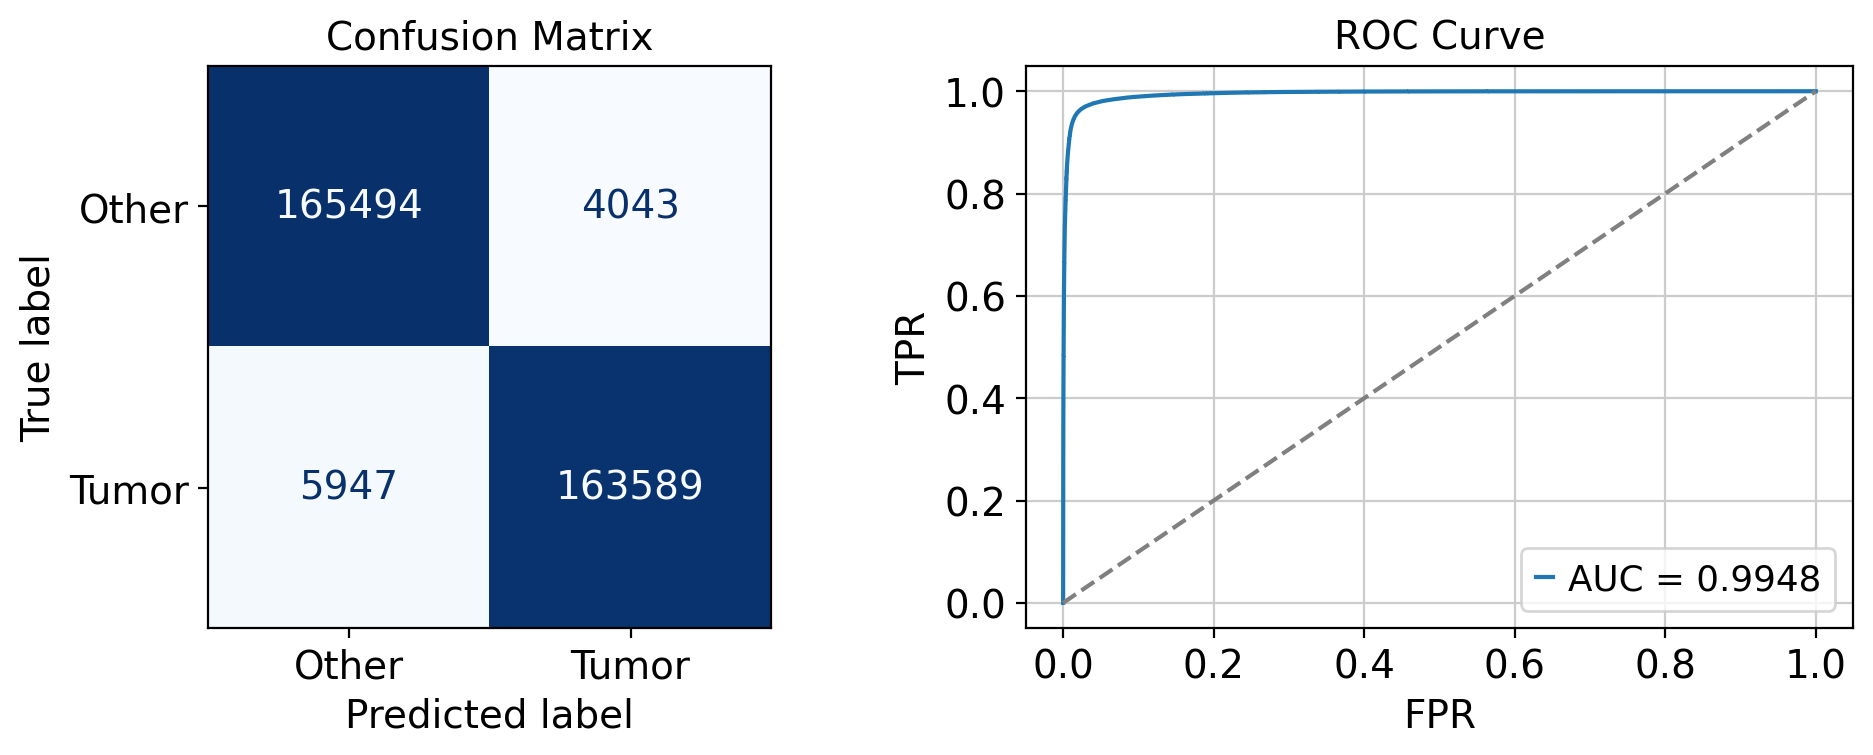

FP=4043, FN=5947, TN=165494, TP=163589


In [25]:
# 評価
print("=" * 60)
print("Evaluation: tumor_other")
print("=" * 60)

results_to = evaluate_model(model_to, data_to, class_names=["Other", "Tumor"])

In [26]:
# チェックポイント保存（~/.spatnic/weights/ に自動保存）
_tmp_sd = "_tmp_tumor_other_sd.pth"
torch.save(
    {k: v.cpu() for k, v in model_to.state_dict().items()},
    _tmp_sd,
)

export_checkpoint(
    state_dict_path=_tmp_sd,
    gene_names=list(data_to["gene_names"]),
    mu_g=data_to["mu_g"],
    std_g=data_to["std_g"],
    model_name="tumor_other",
    label_map={0: "Other", 1: "Tumor"},
)

os.remove(_tmp_sd)

[SPATNIC] Checkpoint saved to /home/shusakai/.spatnic/weights/tumor_other.pt (20.9 MB)


---
## 6. Verification

エクスポートしたチェックポイントで `spatnic.predict` が動くか確認する。

In [27]:
import spatnic

# tumor_normal
print("=" * 60)
print("Verifying tumor_normal checkpoint...")
print("=" * 60)
adata_test = adata_raw[adata_raw.obs["Major_cluster"] == "Epithelial"][:1000].copy()
spatnic.predict(adata_test, model="tumor_normal")
print(adata_test.obs["spatnic_pred"].value_counts())
print()

Verifying tumor_normal checkpoint...
[SPATNIC] Matched genes: 3000/3000 (100.0%)


/home/shusakai/miniconda3/envs/deep/lib/python3.10/site-packages/scipy/sparse/_index.py:188: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)


[SPATNIC] Predictions: Normal=225, Tumor=775
spatnic_pred
Tumor     775
Normal    225
Name: count, dtype: int64



In [28]:
# tumor_other
print("=" * 60)
print("Verifying tumor_other checkpoint...")
print("=" * 60)
adata_test2 = adata_raw[:1000].copy()
spatnic.predict(adata_test2, model="tumor_other")
print(adata_test2.obs["spatnic_pred"].value_counts())

Verifying tumor_other checkpoint...
[SPATNIC] Matched genes: 3000/3000 (100.0%)


/home/shusakai/miniconda3/envs/deep/lib/python3.10/site-packages/scipy/sparse/_index.py:188: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray_sparse(i, j, x)


[SPATNIC] Predictions: Other=387, Tumor=613
spatnic_pred
Tumor    613
Other    387
Name: count, dtype: int64


In [29]:
# メモリ解放
del adata_raw, adata_epi
del model_tn, model_to
del data_tn, data_to
import gc; gc.collect()
torch.cuda.empty_cache()

print("Done!")

Done!
